In [48]:
import scanpy as sc
import scarches
from scarches.models.scpoli import scPoli
import scib
import os
import anndata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
import re

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scvi/_settings.py:63: UserWarning: Since v1.0.0, scvi-tools no longer uses a random seed by default. Run `scvi.settings.seed = 0` to reproduce results from previous versions.
  self.seed = seed
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scvi/_settings.py:70: UserWarning: Setting `dl_pin_memory_gpu_training` is deprecated in v1.0 and will be removed in v1.1. Please pass in `pin_memory` to the data loaders instead.
  self.dl_pin_memory_gpu_training = (
 captum (see https://github.com/pytorch/captum).


# Prepare reference

In [ ]:
###ref已保存

# Prepare query data

In [ ]:
adata_new = sc.read_h5ad("./output_all_human260420/merged.h5ad") # from 1_preprocessing.ipynb
# adata_bashore.obs["sample"] = [sample + "_Bashore" for sample in adata_bashore.obs["sample"]]
#map gene ids to ensembl
ensembl_id_df = pd.read_csv("../../gene_names_to_ensembl_ALLFOUND_allfernandez_no6_withallslysz.csv")
gene_to_ensembl = dict(zip(ensembl_id_df['gene_name'], ensembl_id_df['ensembl_id']))
# Map the variable names in AnnData
adata_new.var['original_gene_names'] = adata_new.var_names
adata_new.var_names = [gene_to_ensembl[gene] if gene in gene_to_ensembl else gene for gene in adata_new.var_names]

In [ ]:
adata_new = sc.read_h5ad("./output_all_human260420/merged.h5ad") 

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/anndata/_core/anndata.py:1897: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [ ]:
import numpy as np
from scipy import sparse

X = adata_new.X

if sparse.issparse(X):
    vals = X.data
else:
    vals = X.ravel()

print("min:", vals.min())
print("max:", vals.max())
print("mean:", vals.mean())
print("has decimals:", np.any(vals[:10000] % 1 != 0))

min: 1
max: 98291
mean: 3.538402708809296
has decimals: False


In [ ]:
non_ENSG_vars = adata_new.var_names[~adata_new.var_names.str.startswith('ENSG')]

In [ ]:
# remove not mapped genes
# Convert non_ENSG_vars to a set for faster lookup
non_ENSG_vars_set = set(non_ENSG_vars)

# Filter out the variables that are in non_ENSG_vars_set
adata_new = adata_new[:, ~adata_new.var_names.isin(non_ENSG_vars_set)]

In [ ]:
adata_new

View of AnnData object with n_obs × n_vars = 551694 × 94473
    obs: 'dataset', 'sample', 'symptoms', 'gender', 'age', 'intervention', 'location', 'scDblFinder.sample', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'patient'
    var: 'original_gene_names'
    obsm: 'decontX_GSE131778_1_UMAP', 'decontX_GSE131778_2_UMAP', 'decontX_GSE131778_3_UMAP', 'decontX_GSE131778_4_UMAP', 'decontX_GSE131778_5_UMAP', 'decontX_GSE131778_6_UMAP', 'decontX_GSE131778_7_UMAP', 'decontX_GSE131778_8_UMAP', 'decontX_GSE143921_1_UMAP', 'decontX_GSE143921_2_UMAP', 'decontX_GSE143921_3_UMAP', 'decontX_GSE143921_4_UMAP', 'decontX_GSE143921_5_UMAP', 'decontX_GSE143921_6_UMAP', 'decontX_GSE155468_10_UMAP', 'decontX_GSE155468_11_UMAP', 'decontX_GSE155468_1_UMAP', 'decontX_GSE155468_2_UMAP', 'decontX_GSE155468_3_UMAP', 'decontX_GSE1

In [ ]:
adata_new.obs['dataset'].value_counts()

dataset
GSE226492    96108
GSE224587    82055
GSE253904    77112
GSE234077    66946
GSE155468    47271
GSE159677    45581
GSE210152    30415
GSE196943    26330
GSE179159    20262
GSE166676    12427
GSE131778    11501
GSE224273     9931
GSE155512     8866
GSE143921     6058
GSE247238     4752
GSE237230     4386
GSE184073     1693
Name: count, dtype: int64

In [ ]:
adata_new.obs['location'].value_counts()

location
Aorta              248305
Carotid Artery     223555
Coronary Artery     44003
Femoral Artery      35831
Name: count, dtype: int64

In [ ]:
adata_new.obs = adata_new.obs.rename(columns={'location': 'tissue'})

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/anndata/_core/anndata.py:1897: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/anndata/_core/anndata.py:1899: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [ ]:
adata_new

AnnData object with n_obs × n_vars = 551694 × 94473
    obs: 'dataset', 'sample', 'symptoms', 'gender', 'age', 'intervention', 'tissue', 'scDblFinder.sample', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'patient'
    var: 'original_gene_names'
    obsm: 'decontX_GSE131778_1_UMAP', 'decontX_GSE131778_2_UMAP', 'decontX_GSE131778_3_UMAP', 'decontX_GSE131778_4_UMAP', 'decontX_GSE131778_5_UMAP', 'decontX_GSE131778_6_UMAP', 'decontX_GSE131778_7_UMAP', 'decontX_GSE131778_8_UMAP', 'decontX_GSE143921_1_UMAP', 'decontX_GSE143921_2_UMAP', 'decontX_GSE143921_3_UMAP', 'decontX_GSE143921_4_UMAP', 'decontX_GSE143921_5_UMAP', 'decontX_GSE143921_6_UMAP', 'decontX_GSE155468_10_UMAP', 'decontX_GSE155468_11_UMAP', 'decontX_GSE155468_1_UMAP', 'decontX_GSE155468_2_UMAP', 'decontX_GSE155468_3_UMAP', 'decontX_GSE155468_4_UM

In [ ]:
adata_new.obs['tissue'].value_counts()

tissue
Aorta              248305
Carotid Artery     223555
Coronary Artery     44003
Femoral Artery      35831
Name: count, dtype: int64

In [ ]:
adata_new.obs_names_make_unique()

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/anndata/utils.py:260: UserWarning: Suffix used (-[0-9]+) to deduplicate index values may make index values difficult to interpret. There values with a similar suffixes in the index. Consider using a different delimiter by passing `join={delimiter}`Example key collisions generated by the make_index_unique algorithm: ['GCAACCGTCTCTGACC-1', 'ATCGTAGGTCCACTCT-1', 'ATGTCCCTCTCGTGAA-1', 'GAGAAATAGCCTGAAG-1', 'TGAGGAGCAAGGAGTC-1']
  warnings.warn(


In [ ]:
adata_new.obs = adata_new.obs.drop(columns='patient')

In [ ]:
adata_new.write("./output_all_human260420/human_mergerd_aggpre.h5ad")

In [ ]:
adata_new.obs

,dataset,sample,symptoms,gender,age,intervention,tissue,scDblFinder.sample,scDblFinder.class,scDblFinder.score,scDblFinder.weighted,scDblFinder.cxds_score,decontX_contamination,decontX_clusters,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,n_genes,n_counts
AACCAAGGCCT,GSE143921,GSE143921_1,TAA,Unknown,Unknown,None,Aorta,GSE143921_1,doublet,0.706048,0.748703,0.976763,0.110604,GSE143921_1-1,123,445.000000,0.000000,0.000000,123,445.000000
AACCAGAGTAT,GSE143921,GSE143921_1,TAA,Unknown,Unknown,None,Aorta,GSE143921_1,singlet,0.143381,0.707147,0.972671,0.164756,GSE143921_1-1,212,2277.000000,0.000000,0.000000,212,2276.000000
AACCAGATAGT,GSE143921,GSE143921_1,TAA,Unknown,Unknown,None,Aorta,GSE143921_1,singlet,0.190519,0.434326,0.169728,0.068149,GSE143921_1-1,147,421.000000,0.000000,0.000000,147,421.000000
AACCAGCCATC,GSE143921,GSE143921_1,TAA,Unknown,Unknown,None,Aorta,GSE143921_1,singlet,0.276413,0.810242,0.868421,0.179043,GSE143921_1-1,105,288.000000,0.000000,0.000000,105,288.000000
AACCAGTAATA,GSE143921,GSE143921_1,TAA,Unknown,Unknown,None,Aorta,GSE143921_1,singlet,0.297798,0.451110,0.425163,0.151484,GSE143921_1-1,125,314.000000,0.000000,0.000000,125,314.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GACCTGGGTCTTCAAG_H_plaque,GSE196943,GSE196943_8,Atherosclerosis,Unknown,Unknown,Unknown,Coronary Artery,GSE196943_8,singlet,0.001740,0.343851,0.073280,0.183490,GSE196943_8-2,752,1456.041563,32.478570,2.230607,752,1456.041563
TGGGCGTTCTTCTGGC_H_plaque,GSE196943,GSE196943_8,Atherosclerosis,Unknown,Unknown,Unknown,Coronary Artery,GSE196943_8,singlet,0.022267,0.140280,0.084446,0.131671,GSE196943_8-2,648,1383.647594,32.959644,2.382084,648,1383.647594
GAGCAGATCAGAGGTG_H_plaque,GSE196943,GSE196943_8,Atherosclerosis,Unknown,Unknown,Unknown,Coronary Artery,GSE196943_8,singlet,0.008174,0.165723,0.079894,0.097733,GSE196943_8-2,639,1354.056503,35.647680,2.632658,639,1354.056503
GAGTCCGGTTCTGGTA_H_plaque,GSE196943,GSE196943_8,Atherosclerosis,Unknown,Unknown,Unknown,Coronary Artery,GSE196943_8,singlet,0.004912,0.741769,0.028802,0.222593,GSE196943_8-1,3322,3094.891555,28.978950,0.936348,3322,3091.032979


In [ ]:
adata_new

AnnData object with n_obs × n_vars = 551694 × 94473
    obs: 'dataset', 'sample', 'symptoms', 'gender', 'age', 'intervention', 'tissue', 'scDblFinder.sample', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts'
    var: 'original_gene_names'
    obsm: 'decontX_GSE131778_1_UMAP', 'decontX_GSE131778_2_UMAP', 'decontX_GSE131778_3_UMAP', 'decontX_GSE131778_4_UMAP', 'decontX_GSE131778_5_UMAP', 'decontX_GSE131778_6_UMAP', 'decontX_GSE131778_7_UMAP', 'decontX_GSE131778_8_UMAP', 'decontX_GSE143921_1_UMAP', 'decontX_GSE143921_2_UMAP', 'decontX_GSE143921_3_UMAP', 'decontX_GSE143921_4_UMAP', 'decontX_GSE143921_5_UMAP', 'decontX_GSE143921_6_UMAP', 'decontX_GSE155468_10_UMAP', 'decontX_GSE155468_11_UMAP', 'decontX_GSE155468_1_UMAP', 'decontX_GSE155468_2_UMAP', 'decontX_GSE155468_3_UMAP', 'decontX_GSE155468_4_UMAP', 'decon

In [ ]:
#aggregation-----------.py在z7_mapping_with_new文件夹下
from scipy.sparse import issparse
import scipy.sparse as sparse
# Convert the sparse matrix (if it is sparse) to a dense DataFrame
adata_df = pd.DataFrame(adata_new.X.toarray() if issparse(adata_new.X) else adata_new.X, 
                        index=adata_new.obs_names, 
                        columns=adata_new.var_names)

# Group by gene names and sum the counts
aggregated_data = adata_df.groupby(adata_df.columns, axis=1).sum()

# Prepare the new 'var' DataFrame, keeping the first occurrence of each gene
unique_var = adata_new.var.loc[~adata_new.var.index.duplicated(keep='first')]

# Create a new AnnData object with aggregated data
adata_agg = anndata.AnnData(X=aggregated_data, obs=adata_new.obs, var=unique_var.loc[aggregated_data.columns])

# 'adata_agg' now has unique gene names and aggregated counts

adata_agg.X = sparse.csr_matrix(adata_agg.X)
adata_agg.write("./output_all_human260420/mergerd_aggregated.h5ad")

In [ ]:
adata_agg = sc.read_h5ad("./output_all_human260420/merged_aggregated.h5ad")
adata_agg

AnnData object with n_obs × n_vars = 551694 × 52067
    obs: 'dataset', 'sample', 'symptoms', 'gender', 'age', 'intervention', 'tissue', 'scDblFinder.sample', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts'
    var: 'original_gene_names'
    layers: 'raw_decontXcounts', 'uncorrected_counts'

In [ ]:
adata = sc.read_h5ad("./output_all_human260420/human_mergerd_aggpre.h5ad")
adata

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/anndata/_core/anndata.py:1899: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


AnnData object with n_obs × n_vars = 551694 × 94473
    obs: 'dataset', 'sample', 'symptoms', 'gender', 'age', 'intervention', 'tissue', 'scDblFinder.sample', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts'
    var: 'original_gene_names'
    obsm: 'decontX_GSE131778_1_UMAP', 'decontX_GSE131778_2_UMAP', 'decontX_GSE131778_3_UMAP', 'decontX_GSE131778_4_UMAP', 'decontX_GSE131778_5_UMAP', 'decontX_GSE131778_6_UMAP', 'decontX_GSE131778_7_UMAP', 'decontX_GSE131778_8_UMAP', 'decontX_GSE143921_1_UMAP', 'decontX_GSE143921_2_UMAP', 'decontX_GSE143921_3_UMAP', 'decontX_GSE143921_4_UMAP', 'decontX_GSE143921_5_UMAP', 'decontX_GSE143921_6_UMAP', 'decontX_GSE155468_10_UMAP', 'decontX_GSE155468_11_UMAP', 'decontX_GSE155468_1_UMAP', 'decontX_GSE155468_2_UMAP', 'decontX_GSE155468_3_UMAP', 'decontX_GSE155468_4_UMAP', 'decon

In [ ]:
from scipy.sparse import issparse
import scipy.sparse as sparse
# MANUALLY CHECK IF SUMMATION WORKED AS INTENDED(做验证)
# Extract counts for "ENSG00000033050" from the original adata
original_counts = adata[:, "ENSG00000033050"].X
if issparse(original_counts):
    original_counts = original_counts.toarray()  # Convert to dense array if sparse

# Sum these counts cellwise
summed_counts = np.sum(original_counts, axis=1)

# Extract counts for "ENSG00000033050" from adata_agg
agg_counts = adata_agg[:, "ENSG00000033050"].X
if issparse(agg_counts):
    agg_counts = agg_counts.toarray()  # Convert to dense array if sparse

# Compare the two sets of counts
comparison = np.allclose(summed_counts.flatten(), agg_counts.flatten())

# Print the result of the comparison
print(f"The counts are correctly summed: {comparison}")


The counts are correctly summed: True


In [ ]:
# # Function to aggregate a layer
# def aggregate_layer(layer):
#     layer_df = pd.DataFrame(layer.toarray() if issparse(layer) else layer, 
#                             index=adata.obs_names, 
#                             columns=adata.var_names)
#     return layer_df.groupby(layer_df.columns, axis=1).sum()

# # Aggregate each layer and add to adata_agg
# for layer_name in adata.layers.keys():
#     print(f"Aggregating layer: {layer_name}")
#     aggregated_layer = aggregate_layer(adata.layers[layer_name])
    
#     # The first time, we need to initialize layers in adata_agg
#     if not hasattr(adata_agg, 'layers'):
#         adata_agg.layers = {}

#     # Add the aggregated layer to adata_agg
#     adata_agg.layers[layer_name] = aggregated_layer

# # Now 'adata_agg' contains all the aggregated layers
#####.py

In [ ]:
def sum_gene_counts(layer, gene_name, var_names):
    # Find the index(es) of the gene
    gene_indices = np.where(var_names == gene_name)[0]

    # Sum counts across all occurrences of the gene
    gene_counts = np.sum(layer[:, gene_indices].toarray(), axis=1) if issparse(layer) else np.sum(layer[:, gene_indices], axis=1)
    return gene_counts

# Check for each layer
for layer_name in adata.layers.keys():
    print(f"Checking layer: {layer_name}")

    # Get var names for the current layer
    var_names = adata.var_names

    # Sum counts for "ENSG00000033050" in the original data
    original_counts = sum_gene_counts(adata.layers[layer_name], "ENSG00000033050", var_names)

    # Extract counts for "ENSG00000033050" from adata_agg layer
    gene_index_agg = np.where(adata_agg.var_names == "ENSG00000033050")[0]
    agg_counts = adata_agg.layers[layer_name][:, gene_index_agg]
    if issparse(agg_counts):
        agg_counts = agg_counts.toarray()

    # Compare the two sets of counts
    comparison = np.allclose(original_counts.flatten(), agg_counts.flatten())

    # Print the result of the comparison
    print(f"The counts are correctly summed in layer {layer_name}: {comparison}")

Checking layer: raw_decontXcounts


The counts are correctly summed in layer raw_decontXcounts: True
Checking layer: uncorrected_counts
The counts are correctly summed in layer uncorrected_counts: True


In [ ]:
#checks
print("Check how many cells have zero counts for all genes...")
cellwise_sum = adata_agg.X.sum(axis=1)
num_cells_zero_counts = (cellwise_sum == 0).sum()
    
if num_cells_zero_counts>0:
    print(num_cells_zero_counts, " cells were found with 0 counts across all genes! Removing these cells now...")
    adata_agg = adata_agg[cellwise_sum > 0, :]

adata_final = adata_agg.copy()


Check how many cells have zero counts for all genes...
3486  cells were found with 0 counts across all genes! Removing these cells now...


In [ ]:
#normalize
#Perform a clustering for scran normalization in clusters
adata_pp = adata_final.copy()
sc.pp.normalize_total(adata_pp, target_sum=1e6)
sc.pp.log1p(adata_pp)
sc.pp.pca(adata_pp, svd_solver="arpack")
sc.pp.neighbors(adata_pp, n_pcs=30)
sc.tl.leiden(adata_pp, key_added='groups', resolution=0.22)


In [ ]:
import rpy2.rinterface_lib.callbacks
import logging

from rpy2.robjects import pandas2ri
import anndata2ri

# Ignore R warning messages
#Note: this can be commented out to get more verbose R output
rpy2.rinterface_lib.callbacks.logger.setLevel(logging.ERROR)

# Automatically convert rpy2 outputs to pandas dataframes
pandas2ri.activate()
anndata2ri.activate()
%load_ext rpy2.ipython

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/rpy2/robjects/pandas2ri.py:368: DeprecationWarning: The global conversion available with activate() is deprecated and will be removed in the next major release. Use a local converter.
  warnings.warn('The global conversion available with activate() '
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/rpy2/robjects/numpy2ri.py:252: DeprecationWarning: The global conversion available with activate() is deprecated and will be removed in the next major release. Use a local converter.
  warnings.warn('The global conversion available with activate() '
/tmp/ipykernel_244935/2253401465.py:13: DeprecationWarning: The global conversion available with activate() is deprecated and will be removed in the next major release. Use a local converter.
  anndata2ri.activate()


In [ ]:
#Preprocess variables for scran normalization
input_groups = adata_pp.obs['groups']
# data_mat = adata_final.X.T.toarray()
data_mat = adata_final.X.T 

In [ ]:
%%R -i data_mat -i input_groups -o size_factors
library(scran)
library(Matrix)  # 必须加载此包以支持稀疏矩阵

print("转换稀疏格式")
data_mat <- as(data_mat, "dgCMatrix")  # 从Python的CSC转为R的CSC格式

# 计算size factors（直接操作稀疏矩阵）
size_factors <- calculateSumFactors(data_mat, clusters=input_groups, min.mean=0.1)
print("计算结束")

[1] "转换稀疏格式"
[1] "计算结束"


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/rpy2/ipython/rmagic.py:990: DeprecationWarning: The `source` parameter emit a  deprecation warning since IPython 8.0, it had no effects for a long time and will  be removed in future versions.
  displaypub.publish_display_data(


Loading required package: SingleCellExperiment
Loading required package: SummarizedExperiment
Loading required package: MatrixGenerics
Loading required package: matrixStats

Attaching package: ‘MatrixGenerics’

The following objects are masked from ‘package:matrixStats’:

    colAlls, colAnyNAs, colAnys, colAvgsPerRowSet, colCollapse,
    colCounts, colCummaxs, colCummins, colCumprods, colCumsums,
    colDiffs, colIQRDiffs, colIQRs, colLogSumExps, colMadDiffs,
    colMads, colMaxs, colMeans2, colMedians, colMins, colOrderStats,
    colProds, colQuantiles, colRanges, colRanks, colSdDiffs, colSds,
    colSums2, colTabulates, colVarDiffs, colVars, colWeightedMads,
    colWeightedMeans, colWeightedMedians, colWeightedSds,
    colWeightedVars, rowAlls, rowAnyNAs, rowAnys, rowAvgsPerColSet,
    rowCollapse, rowCounts, rowCummaxs, rowCummins, rowCumprods,
    rowCumsums, rowDiffs, rowIQRDiffs, rowIQRs, rowLogSumExps,
    rowMadDiffs, rowMads, rowMaxs, rowMeans2, rowMedians, rowMins,
    rowOr

In [ ]:
del adata_pp

In [ ]:
adata_final.obs['size_factors'] = size_factors

In [ ]:
#Normalize adata 
adata_final.X /= adata_final.obs['size_factors'].values[:,None]
sc.pp.log1p(adata_final)

In [ ]:
adata_final.write_h5ad("./output_all_human260420/mergerd_aggred-log-normalized.h5ad")

# Hvg

In [ ]:
####################################以上是公共数据的处理部分，已经处理完成###################################
#以上公共数据的路径在/home/lixiangyu/zr/Annotate/ANNOTATE_new/7_mapping_new_data/output_all_human260420/mergerd_aggred-log-normalized.h5ad
#########################以下是用新参考模型来得到var_gene,输出文件都在/0521_no_Basophil/output_human#########################

In [2]:
adata_new = sc.read_h5ad("/home/lixiangyu/zr/Annotate/ANNOTATE_new/7_mapping_new_data/output_all_human260420/mergerd_aggred-log-normalized.h5ad")
adata_new

AnnData object with n_obs × n_vars = 548208 × 52067
    obs: 'dataset', 'sample', 'symptoms', 'gender', 'age', 'intervention', 'tissue', 'scDblFinder.sample', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'size_factors'
    var: 'original_gene_names'
    uns: 'log1p'
    layers: 'raw_decontXcounts', 'uncorrected_counts'

In [3]:
adata_new.X.sum()

892921283.3230462

In [4]:
adata_new

AnnData object with n_obs × n_vars = 548208 × 52067
    obs: 'dataset', 'sample', 'symptoms', 'gender', 'age', 'intervention', 'tissue', 'scDblFinder.sample', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'size_factors'
    var: 'original_gene_names'
    uns: 'log1p'
    layers: 'raw_decontXcounts', 'uncorrected_counts'

In [5]:
adata_new.obs['cell_type_level1'] = "unknown"

In [6]:
from scarches.models.base._utils import _validate_var_names

In [7]:
varnames_path = "/home/lixiangyu/zr/Annotate/ANNOTATE_new/4_big_integration/train_ref_model_noBasophil_0521/output/ref_model_noBasophil/var_names.csv"###no correct
var_names = np.genfromtxt(varnames_path, delimiter=",", dtype=str)
adata_query = _validate_var_names(adata_new, var_names)

Query data contains expression data of  50067  genes that were not contained in the reference dataset. This information will be removed from the query data object for further processing.
AnnData object with n_obs × n_vars = 548208 × 2000
    obs: 'dataset', 'sample', 'symptoms', 'gender', 'age', 'intervention', 'tissue', 'scDblFinder.sample', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'size_factors', 'cell_type_level1'
    var: 'original_gene_names'
    uns: 'log1p'
    layers: 'raw_decontXcounts', 'uncorrected_counts'


In [8]:
adata_query

AnnData object with n_obs × n_vars = 548208 × 2000
    obs: 'dataset', 'sample', 'symptoms', 'gender', 'age', 'intervention', 'tissue', 'scDblFinder.sample', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'size_factors', 'cell_type_level1'
    var: 'original_gene_names'
    uns: 'log1p'
    layers: 'raw_decontXcounts', 'uncorrected_counts'

In [9]:
adata_query.write("./output_human/mergerd_aggred-log-normalized-hvg.h5ad")

In [ ]:
#############################训练的.py文件是7_文件夹下(0521_no_Basophil)的/7_integration_human260521_nobasophil.py#####################

####################################################以下在.py文件########################################

# Train query

In [ ]:
################################################以下的训练均在.py文件中#############################################3

In [ ]:
adata_query= sc.read_h5ad("./output_human/mergerd_aggred-log-normalized-hvg-no_correct_2.h5ad")

In [ ]:
scpoli_model = scPoli.load("/home/lixiangyu/zr/Annotate/ANNOTATE_new/4_big_integration/output_260420/model_percorrect/all_measure_no_IAISR", adata=adata_query)

AnnData object with n_obs × n_vars = 302673 × 2000
    obs: 'dataset', 'sample', 'symptoms', 'gender', 'age', 'intervention', 'tissue', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'size_factors', 'cell_type_level1'
    var: 'original_gene_names'
    uns: 'log1p'
Embedding dictionary:
 	Num conditions: [46]
 	Embedding dim: [10]
Encoder Architecture:
	Input Layer in, out and cond: 2000 45 10
	Mean/Var Layer in/out: 45 10
Decoder Architecture:
	First Layer in, out and cond:  10 45 10
	Output Layer in/out:  45 2000 



/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scarches/models/scpoli/scpoli_model.py:156: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  self.obs_metadata_ = adata.obs.groupby(condition_keys).first()


In [46]:
scpoli_query = scPoli.load_query_data(
    adata=adata_query,
    reference_model=scpoli_model,
    labeled_indices=[],
)

Embedding dictionary:
 	Num conditions: [142]
 	Embedding dim: [10]
Encoder Architecture:
	Input Layer in, out and cond: 2000 45 10
	Mean/Var Layer in/out: 45 10
Decoder Architecture:
	First Layer in, out and cond:  10 45 10
	Output Layer in/out:  45 2000 



/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scarches/models/scpoli/scpoli_model.py:777: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  new_obs_metadata = adata.obs.groupby('conditions_combined').first()
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scarches/models/scpoli/scpoli_model.py:156: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  self.obs_metadata_ = adata.obs.groupby(condition_keys).first()


In [ ]:
scpoli_query.train(
    n_epochs=50,
    pretraining_epochs=40,
    eta=10
)
###放在/home/lixiangyu/zr/Annotate/ANNOTATE_new/7_mapping_new_data/.py/model_train/as_atlas.py这个文件后台训练了

In [ ]:
# scpoli_query.save("./output_all_human260420/model_260420/human_all_query-level1", overwrite=True)
scpoli_query.save("./output_human/model_260507/human_all_query-level1-no_IAISR", overwrite=True)

## Create embedding adata

In [ ]:
adata_query = sc.read_h5ad("./output_human/mergerd_aggred-log-normalized-hvg-no_correct_2.h5ad")

In [ ]:
scpoli_query = scPoli.load("./output_human/model_260507/human_all_query-level1-no_IAISR", adata=adata_query)##ref_model

AnnData object with n_obs × n_vars = 302673 × 2000
    obs: 'dataset', 'sample', 'symptoms', 'gender', 'age', 'intervention', 'tissue', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'size_factors', 'cell_type_level1'
    var: 'original_gene_names'
    uns: 'log1p'
Embedding dictionary:
 	Num conditions: [142]
 	Embedding dim: [10]
Encoder Architecture:
	Input Layer in, out and cond: 2000 45 10
	Mean/Var Layer in/out: 45 10
Decoder Architecture:
	First Layer in, out and cond:  10 45 10
	Output Layer in/out:  45 2000 



/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scarches/models/scpoli/scpoli_model.py:156: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  self.obs_metadata_ = adata.obs.groupby(condition_keys).first()


In [50]:
adata_query.X = adata_query.X.astype("float32")

In [51]:
results_dict = scpoli_query.classify(adata_query, scale_uncertainties=True)

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scarches/models/scpoli/scpoli_model.py:454: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:254.)
  c = torch.tensor(label_tensor, device=device).T


In [ ]:
adata = sc.read_h5ad("/home/lixiangyu/zr/Annotate/ANNOTATE_new/4_big_integration/output_260420/big-concat-ensembl-nodub-aggr-scranlog1p-annot-nodoublets-pp_2.h5ad")

In [53]:
#get whole atlas including reference

#get latent representation of reference data
scpoli_query.model.eval()
data_latent_source = scpoli_query.get_latent(
    adata,
    mean=True
)

adata_latent_source = sc.AnnData(data_latent_source)
adata_latent_source.obs = adata.obs.copy()

#get latent representation of query data
data_latent= scpoli_query.get_latent(
    adata_query,
    mean=True
)

adata_latent = sc.AnnData(data_latent)
adata_latent.obs = adata_query.obs.copy()

#get label annotations
adata_latent.obs['cell_type_pred'] = results_dict['cell_type_level1']['preds'].tolist()
adata_latent.obs['cell_type_uncert'] = results_dict['cell_type_level1']['uncert'].tolist()
#adata_latent.obs['classifier_outcome'] = (adata_latent.obs['cell_type_pred'] == adata_latent.obs['cell_type_level1'])

#join adatas
adata_latent_full = adata_latent_source.concatenate(
    [adata_latent],
    batch_key='query'
)


adata_latent_full.obs['cell_type_pred_ref'] = np.where(
    adata_latent_full.obs['query'].isin(['0']),  # Condition
    "Reference",                                # Value if condition is true
    adata_latent_full.obs['cell_type_pred']     # Value if condition is false
)

/tmp/ipykernel_3157653/660821678.py:28: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata_latent_full = adata_latent_source.concatenate(


In [54]:
adata_latent_full.obs

,sample,dataset,symptoms,scDblFinder.sample,scDblFinder.class,scDblFinder.score,scDblFinder.weighted,scDblFinder.cxds_score,decontX_contamination,decontX_clusters,...,cell_type_level1,gender,age,intervention,tissue,n_counts,cell_type_pred,cell_type_uncert,query,cell_type_pred_ref
AAACCCAAGAGGTTAT-1-0,1_1_JD,1_JD,AAA,1,singlet,0.000151,0.308148,0.006895,0.002891,1,...,Monocyte,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,Reference
AAACCCAAGCAACAAT-1-0,1_1_JD,1_JD,AAA,1,singlet,0.000046,0.264894,0.013618,0.002804,1,...,Monocyte,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,Reference
AAACCCAAGGAGTCTG-1-0,1_1_JD,1_JD,AAA,1,singlet,0.000119,0.113871,0.014093,0.029719,2,...,B cell,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,Reference
AAACCCACAACTCATG-1-0,1_1_JD,1_JD,AAA,1,singlet,0.058202,0.276472,0.104606,0.024003,1,...,Dendritic cell,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,Reference
AAACCCAGTCAAGGCA-1-0,1_1_JD,1_JD,AAA,1,singlet,0.000007,0.041986,0.000540,0.001885,4,...,T cell,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,Reference
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GACCTGGGTCTTCAAG_H_plaque-1,GSE196943_8,GSE196943,Atherosclerosis,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,unknown,Unknown,Unknown,Unknown,Coronary Artery,1456.041563,Plasma cell,0.103437,1,Plasma cell
TGGGCGTTCTTCTGGC_H_plaque-1,GSE196943_8,GSE196943,Atherosclerosis,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,unknown,Unknown,Unknown,Unknown,Coronary Artery,1383.647594,Plasma cell,0.233901,1,Plasma cell
GAGCAGATCAGAGGTG_H_plaque-1,GSE196943_8,GSE196943,Atherosclerosis,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,unknown,Unknown,Unknown,Unknown,Coronary Artery,1354.056503,B cell,0.050218,1,B cell
GAGTCCGGTTCTGGTA_H_plaque-1,GSE196943_8,GSE196943,Atherosclerosis,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,unknown,Unknown,Unknown,Unknown,Coronary Artery,3091.032979,Fibroblast,0.676785,1,Fibroblast


In [55]:
adata_latent_full

AnnData object with n_obs × n_vars = 714552 × 10
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.sample', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'Source', 'size_factors', 'cell_type_level1', 'gender', 'age', 'intervention', 'tissue', 'n_counts', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref'

In [56]:
adata_latent_full.obs["cell_type_level1"]

AAACCCAAGAGGTTAT-1-0                 Monocyte
AAACCCAAGCAACAAT-1-0                 Monocyte
AAACCCAAGGAGTCTG-1-0                   B cell
AAACCCACAACTCATG-1-0           Dendritic cell
AAACCCAGTCAAGGCA-1-0                   T cell
                                    ...      
GACCTGGGTCTTCAAG_H_plaque-1           unknown
TGGGCGTTCTTCTGGC_H_plaque-1           unknown
GAGCAGATCAGAGGTG_H_plaque-1           unknown
GAGTCCGGTTCTGGTA_H_plaque-1           unknown
TCATTTGAGTTGTCGT_H_plaque-1           unknown
Name: cell_type_level1, Length: 714552, dtype: category
Categories (14, object): ['B cell', 'Dendritic cell', 'Endothelial cell', 'Fibroblast', ..., 'Plasma cell', 'Smooth muscle cell', 'T cell', 'unknown']

In [57]:
# Create 'cell_type_level1_combined' based on the 'query' condition
adata_latent_full.obs['cell_type_level1_human'] = np.where(
    adata_latent_full.obs['query'] == "0",
    adata_latent_full.obs['cell_type_level1'],
    adata_latent_full.obs['cell_type_pred_ref']
)

In [58]:
adata_latent_full.obs

,sample,dataset,symptoms,scDblFinder.sample,scDblFinder.class,scDblFinder.score,scDblFinder.weighted,scDblFinder.cxds_score,decontX_contamination,decontX_clusters,...,gender,age,intervention,tissue,n_counts,cell_type_pred,cell_type_uncert,query,cell_type_pred_ref,cell_type_level1_human
AAACCCAAGAGGTTAT-1-0,1_1_JD,1_JD,AAA,1,singlet,0.000151,0.308148,0.006895,0.002891,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,Reference,Monocyte
AAACCCAAGCAACAAT-1-0,1_1_JD,1_JD,AAA,1,singlet,0.000046,0.264894,0.013618,0.002804,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,Reference,Monocyte
AAACCCAAGGAGTCTG-1-0,1_1_JD,1_JD,AAA,1,singlet,0.000119,0.113871,0.014093,0.029719,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,Reference,B cell
AAACCCACAACTCATG-1-0,1_1_JD,1_JD,AAA,1,singlet,0.058202,0.276472,0.104606,0.024003,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,Reference,Dendritic cell
AAACCCAGTCAAGGCA-1-0,1_1_JD,1_JD,AAA,1,singlet,0.000007,0.041986,0.000540,0.001885,4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,Reference,T cell
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GACCTGGGTCTTCAAG_H_plaque-1,GSE196943_8,GSE196943,Atherosclerosis,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Unknown,Unknown,Unknown,Coronary Artery,1456.041563,Plasma cell,0.103437,1,Plasma cell,Plasma cell
TGGGCGTTCTTCTGGC_H_plaque-1,GSE196943_8,GSE196943,Atherosclerosis,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Unknown,Unknown,Unknown,Coronary Artery,1383.647594,Plasma cell,0.233901,1,Plasma cell,Plasma cell
GAGCAGATCAGAGGTG_H_plaque-1,GSE196943_8,GSE196943,Atherosclerosis,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Unknown,Unknown,Unknown,Coronary Artery,1354.056503,B cell,0.050218,1,B cell,B cell
GAGTCCGGTTCTGGTA_H_plaque-1,GSE196943_8,GSE196943,Atherosclerosis,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Unknown,Unknown,Unknown,Coronary Artery,3091.032979,Fibroblast,0.676785,1,Fibroblast,Fibroblast


In [59]:
adata_latent_full.obs["cell_type_level1_human"]

AAACCCAAGAGGTTAT-1-0                 Monocyte
AAACCCAAGCAACAAT-1-0                 Monocyte
AAACCCAAGGAGTCTG-1-0                   B cell
AAACCCACAACTCATG-1-0           Dendritic cell
AAACCCAGTCAAGGCA-1-0                   T cell
                                    ...      
GACCTGGGTCTTCAAG_H_plaque-1       Plasma cell
TGGGCGTTCTTCTGGC_H_plaque-1       Plasma cell
GAGCAGATCAGAGGTG_H_plaque-1            B cell
GAGTCCGGTTCTGGTA_H_plaque-1        Fibroblast
TCATTTGAGTTGTCGT_H_plaque-1        Macrophage
Name: cell_type_level1_human, Length: 714552, dtype: object

In [ ]:
adata_latent_full.write_h5ad("./output_all_human260420/level1_human_preump.h5ad")

In [61]:
sc.pp.neighbors(adata_latent_full, n_neighbors=15)
sc.tl.umap(adata_latent_full)

In [ ]:
adata_latent_full.write_h5ad("./output_all_human260420/level1_human_atlas_nogene.h5ad")

######################################以上在.py#########################################

# umap_plot

In [1]:
import scanpy as sc
adata_nobasophil = sc.read_h5ad("./output_human/level1_human_atlas_nogene_umap.h5ad")
adata_nobasophil

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/anndata/_core/anndata.py:1897: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


AnnData object with n_obs × n_vars = 1019688 × 10
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'size_factors', 'leiden', 'cell_type_level1', 'scDblFinder.sample', 'gender', 'age', 'intervention', 'tissue', 'atlas_key', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'cell_type_level1_human'
    uns: 'neighbors', 'umap'
    obsm: 'X_umap'
    obsp: 'connectivities', 'distances'

In [2]:
adata_new = adata_nobasophil[adata_nobasophil.obs['query'] != "0"]
adata_new.obs["cell_type_level1_human"].value_counts()

cell_type_level1_human
T cell                   186955
B cell                    56357
Macrophage                53007
Natural killer cell       49651
Fibroblast                48679
Smooth muscle cell        43726
Endothelial cell          30848
Dendritic cell            26823
Monocyte                  17511
Neutrophil                13967
Pericyte                   9906
Erythrocyte/Erythroid      6348
Mast cell                  4430
Name: count, dtype: int64

In [3]:
# for corrected2
color_palette_level1 = {
    'T cell': '#3182bd',                       # blue for all T cell types
    'Macrophage': '#8c564b',                   # brown for all macrophages
    'Erythrocyte/Erythroid': '#ff7f0e',                  # vibrant orange
    'Mast cell': '#d62728',                    # red
    'Natural killer cell': '#98df8a',                      # light green
    'Pericyte': '#f7b6d2',                 # pastel pink
    'Smooth muscle cell': '#7b4173',           # deeper purple
    'Fibroblast': '#e377c2',                   # bright pink
    'B cell': '#2ca02c',                       # green
    'Dendritic cell': '#807dba',               # violet for dendritic cells
    'Endothelial cell': '#fdae6b',                           # orange for all endothelial cells  
    'Monocyte': '#c7c7c7',                     # lighter gray
    'Neutrophil': '#17becf',
    'Basophil': '#ac8d62',
    'Reference' : 'white'               # teal
}

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


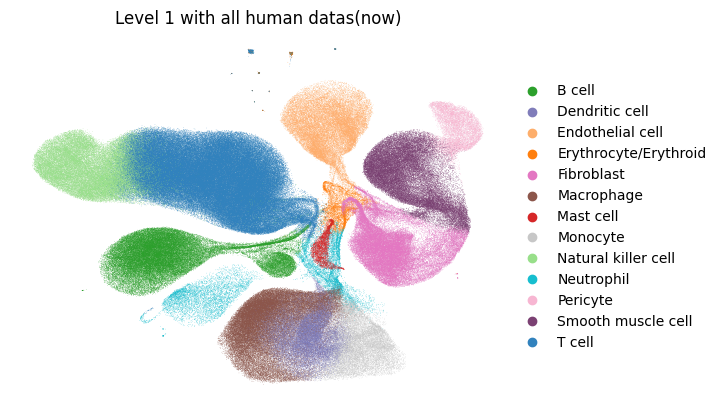

In [8]:
# Plot UMAP with custom color palette---2.0有IAISR
sc.pl.umap(
    adata_new,
    color='cell_type_level1_human',
    palette=color_palette_level1,
    size=0.5,
    show=True,
    frameon=False,
    title = "Level 1 with all human datas(now)",
    save="level1-now.pdf"
)

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


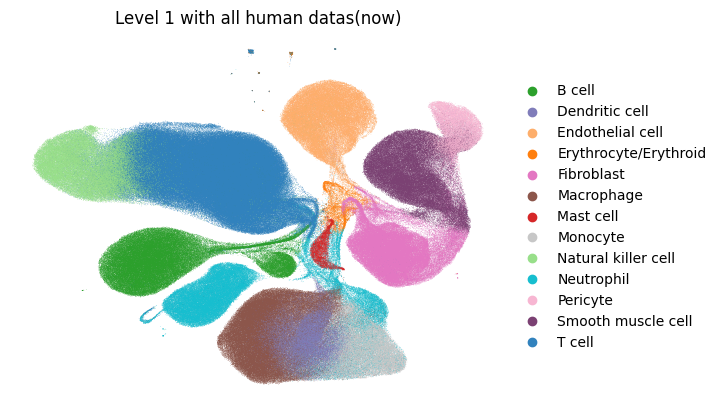

In [9]:
# Plot UMAP with custom color palette---2.0有IAISR
sc.pl.umap(
    adata_nobasophil,
    color='cell_type_level1_human',
    palette=color_palette_level1,
    size=0.5,
    show=True,
    frameon=False,
    title = "Level 1 with all human datas(now)",
    save="level1-now.pdf"
)

# transfer all gene new-0521


In [10]:
adata_latent_full_filtered = sc.read_h5ad("./output_human/level1_human_atlas_nogene_umap.h5ad") 

# 得到只有公共数据
adata_new = adata_latent_full_filtered[adata_latent_full_filtered.obs['cell_type_pred_ref'] != "Reference"]
adata_new.obs.index = adata_new.obs.index.str[:-2]
adata_new.obs

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/anndata/_core/anndata.py:1897: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


,sample,dataset,symptoms,scDblFinder.class,scDblFinder.score,scDblFinder.weighted,scDblFinder.cxds_score,decontX_contamination,decontX_clusters,n_genes_by_counts,...,gender,age,intervention,tissue,atlas_key,cell_type_pred,cell_type_uncert,query,cell_type_pred_ref,cell_type_level1_human
AACCAAGGCCT,GSE143921_1,GSE143921,TAA,doublet,0.706048,0.748703,0.976763,0.110604,GSE143921_1-1,123,...,Unknown,Unknown,None,Aorta,NaN,Fibroblast,0.235129,1,Fibroblast,Fibroblast
AACCAGAGTAT,GSE143921_1,GSE143921,TAA,singlet,0.143381,0.707147,0.972671,0.164756,GSE143921_1-1,212,...,Unknown,Unknown,None,Aorta,NaN,Smooth muscle cell,0.230128,1,Smooth muscle cell,Smooth muscle cell
AACCAGATAGT,GSE143921_1,GSE143921,TAA,singlet,0.190519,0.434326,0.169728,0.068149,GSE143921_1-1,147,...,Unknown,Unknown,None,Aorta,NaN,Erythrocyte/Erythroid,0.356013,1,Erythrocyte/Erythroid,Erythrocyte/Erythroid
AACCAGCCATC,GSE143921_1,GSE143921,TAA,singlet,0.276413,0.810242,0.868421,0.179043,GSE143921_1-1,105,...,Unknown,Unknown,None,Aorta,NaN,Fibroblast,0.465836,1,Fibroblast,Fibroblast
AACCAGTAATA,GSE143921_1,GSE143921,TAA,singlet,0.297798,0.451110,0.425163,0.151484,GSE143921_1-1,125,...,Unknown,Unknown,None,Aorta,NaN,Erythrocyte/Erythroid,0.436949,1,Erythrocyte/Erythroid,Erythrocyte/Erythroid
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GACCTGGGTCTTCAAG_H_plaque,GSE196943_8,GSE196943,Atherosclerosis,singlet,0.001740,0.343851,0.073280,0.183490,GSE196943_8-2,752,...,Unknown,Unknown,Unknown,Coronary Artery,NaN,B cell,0.036015,1,B cell,B cell
TGGGCGTTCTTCTGGC_H_plaque,GSE196943_8,GSE196943,Atherosclerosis,singlet,0.022267,0.140280,0.084446,0.131671,GSE196943_8-2,648,...,Unknown,Unknown,Unknown,Coronary Artery,NaN,B cell,0.118640,1,B cell,B cell
GAGCAGATCAGAGGTG_H_plaque,GSE196943_8,GSE196943,Atherosclerosis,singlet,0.008174,0.165723,0.079894,0.097733,GSE196943_8-2,639,...,Unknown,Unknown,Unknown,Coronary Artery,NaN,B cell,0.066340,1,B cell,B cell
GAGTCCGGTTCTGGTA_H_plaque,GSE196943_8,GSE196943,Atherosclerosis,singlet,0.004912,0.741769,0.028802,0.222593,GSE196943_8-1,3322,...,Unknown,Unknown,Unknown,Coronary Artery,NaN,Neutrophil,0.591841,1,Neutrophil,Neutrophil


In [11]:
adata_new

View of AnnData object with n_obs × n_vars = 548208 × 10
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'size_factors', 'leiden', 'cell_type_level1', 'scDblFinder.sample', 'gender', 'age', 'intervention', 'tissue', 'atlas_key', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'cell_type_level1_human'
    uns: 'neighbors', 'umap'
    obsm: 'X_umap'
    obsp: 'connectivities', 'distances'

In [12]:
adata_new.obs['cell_type_level1'].value_counts()

cell_type_level1
unknown    548208
Name: count, dtype: int64

In [13]:
adata_new.obs['cell_type_pred'].value_counts()

cell_type_pred
T cell                   186955
B cell                    56357
Macrophage                53007
Natural killer cell       49651
Fibroblast                48679
Smooth muscle cell        43726
Endothelial cell          30848
Dendritic cell            26823
Monocyte                  17511
Neutrophil                13967
Pericyte                   9906
Erythrocyte/Erythroid      6348
Mast cell                  4430
Name: count, dtype: int64

In [14]:
adata_new.obs['cell_type_level1_human'].value_counts()

cell_type_level1_human
T cell                   186955
B cell                    56357
Macrophage                53007
Natural killer cell       49651
Fibroblast                48679
Smooth muscle cell        43726
Endothelial cell          30848
Dendritic cell            26823
Monocyte                  17511
Neutrophil                13967
Pericyte                   9906
Erythrocyte/Erythroid      6348
Mast cell                  4430
Name: count, dtype: int64

In [15]:
adata_new_counts = sc.read_h5ad("/home/lixiangyu/zr/Annotate/ANNOTATE_new/7_mapping_new_data/output_all_human260420/mergerd_aggred-log-normalized.h5ad")##标准化后的公共人类
common_new = adata_new.obs.index.intersection(adata_new_counts.obs.index)

In [16]:
# Subset both AnnData objects to the common barcodes
adata_new = adata_new[common_new].copy()
adata_new_counts = adata_new_counts[common_new].copy()
level1 = adata_new.obs["cell_type_level1_human"].values##预测的标签
adata_new_counts.obs["cell_type_level1"] = level1##给归一化后的数据-[cell_type_level1_human = cell_type_pred]

In [17]:
adata_new_counts

AnnData object with n_obs × n_vars = 548208 × 52067
    obs: 'dataset', 'sample', 'symptoms', 'gender', 'age', 'intervention', 'tissue', 'scDblFinder.sample', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'size_factors', 'cell_type_level1'
    var: 'original_gene_names'
    uns: 'log1p'
    layers: 'raw_decontXcounts', 'uncorrected_counts'

In [18]:
adata_new_counts.obs['cell_type_level1'].value_counts()

cell_type_level1
T cell                   186955
B cell                    56357
Macrophage                53007
Natural killer cell       49651
Fibroblast                48679
Smooth muscle cell        43726
Endothelial cell          30848
Dendritic cell            26823
Monocyte                  17511
Neutrophil                13967
Pericyte                   9906
Erythrocyte/Erythroid      6348
Mast cell                  4430
Name: count, dtype: int64

In [19]:
##有annot,.X矩阵是标准化后的
adata_new_counts.write('./output_human/query_human_atlas_allgene_annot.h5ad')
adata_new_counts.var

,original_gene_names
ENSG00000121410,A1BG
ENSG00000268895,A1BG-AS1
ENSG00000148584,A1CF
ENSG00000175899,A2M
ENSG00000245105,A2M-AS1
...,...
ENSG00000277541,ZNF630-AS1
ENSG00000221874,ZNF816-ZNF321P
ENSG00000212643,ZRSR1
ENSG00000272920,hsa-mir-1253


In [ ]:
adata_new_annot = sc.read_h5ad('./output_human/query_human_atlas_allgene_annot.h5ad')

In [20]:
adata_new_counts.obs["cell_type_level1"].value_counts()

cell_type_level1
T cell                   186955
B cell                    56357
Macrophage                53007
Natural killer cell       49651
Fibroblast                48679
Smooth muscle cell        43726
Endothelial cell          30848
Dendritic cell            26823
Monocyte                  17511
Neutrophil                13967
Pericyte                   9906
Erythrocyte/Erythroid      6348
Mast cell                  4430
Name: count, dtype: int64

In [ ]:
###############不能用之前的size_factor,必须得重新计算才行，所以下面这个直接把annot给原始counts数据#############

In [21]:
adata_new = sc.read_h5ad("../output_all_human260420/merged_aggregated.h5ad")##聚合之后的数据
adata_new_annot = sc.read_h5ad('./output_human/query_human_atlas_allgene_annot.h5ad')
adata_new_annot

AnnData object with n_obs × n_vars = 548208 × 52067
    obs: 'dataset', 'sample', 'symptoms', 'gender', 'age', 'intervention', 'tissue', 'scDblFinder.sample', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'size_factors', 'cell_type_level1'
    var: 'original_gene_names'
    uns: 'log1p'
    layers: 'raw_decontXcounts', 'uncorrected_counts'

In [22]:
adata_new_annot.obs["cell_type_level1"].value_counts()

cell_type_level1
T cell                   186955
B cell                    56357
Macrophage                53007
Natural killer cell       49651
Fibroblast                48679
Smooth muscle cell        43726
Endothelial cell          30848
Dendritic cell            26823
Monocyte                  17511
Neutrophil                13967
Pericyte                   9906
Erythrocyte/Erythroid      6348
Mast cell                  4430
Name: count, dtype: int64

In [23]:
###检查
import numpy as np
from scipy import sparse

Y = adata_new_annot.X

if sparse.issparse(Y):
    print(np.all(Y.data == np.rint(Y.data)))
else:
    print(np.all(Y == np.rint(Y)))

False


In [24]:
##检查
import numpy as np
from scipy import sparse

Y = adata_new.X

if sparse.issparse(Y):
    print(np.all(Y.data == np.rint(Y.data)))
else:
    print(np.all(Y == np.rint(Y)))

True


In [25]:
adata_new_annot.var

,original_gene_names
ENSG00000121410,A1BG
ENSG00000268895,A1BG-AS1
ENSG00000148584,A1CF
ENSG00000175899,A2M
ENSG00000245105,A2M-AS1
...,...
ENSG00000277541,ZNF630-AS1
ENSG00000221874,ZNF816-ZNF321P
ENSG00000212643,ZRSR1
ENSG00000272920,hsa-mir-1253


In [26]:
adata_new.var

,original_gene_names
ENSG00000121410,A1BG
ENSG00000268895,A1BG-AS1
ENSG00000148584,A1CF
ENSG00000175899,A2M
ENSG00000245105,A2M-AS1
...,...
ENSG00000277541,ZNF630-AS1
ENSG00000221874,ZNF816-ZNF321P
ENSG00000212643,ZRSR1
ENSG00000272920,hsa-mir-1253


In [27]:
# 3. 确保 annotated 文件里的 cells 都在 counts 文件里
print(adata_new_annot.obs_names.isin(adata_new.obs_names).all())
# 4. subset counts 数据，只保留有注释的 cells，并按注释文件顺序排列
adata_new = adata_new[adata_new_annot.obs_names].copy()

True


In [28]:
# 5. 把注释从 log-normalized 文件转移到 counts 文件
adata_new.obs["cell_type_level1"] = (
    adata_new_annot.obs["cell_type_level1"]
    .reindex(adata_new.obs_names)
    .values)
print(adata_new.obs["cell_type_level1"].value_counts())

cell_type_level1
T cell                   186955
B cell                    56357
Macrophage                53007
Natural killer cell       49651
Fibroblast                48679
Smooth muscle cell        43726
Endothelial cell          30848
Dendritic cell            26823
Monocyte                  17511
Neutrophil                13967
Pericyte                   9906
Erythrocyte/Erythroid      6348
Mast cell                  4430
Name: count, dtype: int64


In [29]:
# 7. 保存：这是有标签、有 counts 的查询数据
adata_new.write( "./output_human/query_human_atlas_allgene_annot_counts.h5ad")###这个是最终的有注释的counts数据，.X是rounded_corrected_counts，obs里有注释
adata_new

AnnData object with n_obs × n_vars = 548208 × 52067
    obs: 'dataset', 'sample', 'symptoms', 'gender', 'age', 'intervention', 'tissue', 'scDblFinder.sample', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'cell_type_level1'
    var: 'original_gene_names'
    layers: 'raw_decontXcounts', 'uncorrected_counts'

In [30]:
adata_new.obs["cell_type_level1"].value_counts()

cell_type_level1
T cell                   186955
B cell                    56357
Macrophage                53007
Natural killer cell       49651
Fibroblast                48679
Smooth muscle cell        43726
Endothelial cell          30848
Dendritic cell            26823
Monocyte                  17511
Neutrophil                13967
Pericyte                   9906
Erythrocyte/Erythroid      6348
Mast cell                  4430
Name: count, dtype: int64

In [ ]:
#之前拿rounded_corrected_counts
#  检查 adata_new_annot 的细胞是否都在 adata_new 里
adata_new_annot.obs_names.isin(adata_new.obs_names).all()
adata_new_aligned = adata_new[adata_new_annot.obs_names, adata_new_annot.var_names]
adata_new_annot.layers["rounded_corrected_counts"] = adata_new_aligned.X.copy()
adata_new_annot
##拿到了rounded_corrected_counts
# adata_new_annot.write("./output_all_human260420/mergerd_aggred-log-normalized-allgene-counts.h5ad")
# adata_new_annot.write("./output_all_human260420/mergerd_aggred-log-normalized-allgene-counts-no_correct.h5ad")
# adata_new_annot.write("./output_human/mergerd_aggred-log-normalized-allgene-counts-no_IAISR_2.h5ad")###0507的校正和level2—3
adata_new_annot.write("./output_human/mergerd_aggred-log-normalized-allgene-counts-no_IAISR_2_rename.h5ad")###用于校正，现在的.X是log1p的表达矩阵，rounded_corrected_counts才是校正后的counts矩阵

In [ ]:
####################################以上得到的数据用于校正##########以上的数据已经拿到了查询数据注释+原始counts#########################3
######################################################以下用于和参考数据合并#####################################

#### all human data  prepare

参考的allgene：去除dpublets之后 整合之前

In [31]:
adata_new_annot = sc.read_h5ad("./output_human/query_human_atlas_allgene_annot_counts.h5ad")###这个是最终的有注释的counts数据，.X是聚合后的原始counts数据，obs里有注释,如果重新做校正就用这个
adata_new_annot

AnnData object with n_obs × n_vars = 548208 × 52067
    obs: 'dataset', 'sample', 'symptoms', 'gender', 'age', 'intervention', 'tissue', 'scDblFinder.sample', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'cell_type_level1'
    var: 'original_gene_names'
    layers: 'raw_decontXcounts', 'uncorrected_counts'

In [32]:
adata_new_annot.var

,original_gene_names
ENSG00000121410,A1BG
ENSG00000268895,A1BG-AS1
ENSG00000148584,A1CF
ENSG00000175899,A2M
ENSG00000245105,A2M-AS1
...,...
ENSG00000277541,ZNF630-AS1
ENSG00000221874,ZNF816-ZNF321P
ENSG00000212643,ZRSR1
ENSG00000272920,hsa-mir-1253


In [34]:
import pandas as pd
ensembl_id_df = pd.read_csv("../../../gene_names_to_ensembl_ALLFOUND_allfernandez_no6_withallslysz.csv")
ensembl_id_df['gene_name'] = ensembl_id_df['gene_name'].astype(str).str.strip()
ensembl_id_df['ensembl_id'] = ( ensembl_id_df['ensembl_id'].astype(str).str.strip().str.replace(r'\.\d+$', '', regex=True))
# gene_name -> ensembl_id，保留你原来的字典
gene_to_ensembl = dict(zip(ensembl_id_df['gene_name'], ensembl_id_df['ensembl_id']))
# 新增：ensembl_id -> gene_name
ensembl_to_gene = dict(zip(ensembl_id_df['ensembl_id'], ensembl_id_df['gene_name']))
# 当前 var_names 是 Ensembl ID，所以先保存
adata_new_annot.var['ensembl_id'] = (adata_new_annot.var_names.astype(str).str.strip().str.replace(r'\.\d+$', '', regex=True))
# 用 Ensembl ID 映射回 gene symbol，写成新的 original_gene_names
adata_new_annot.var['original_gene_names'] = [
    ensembl_to_gene[x] if x in ensembl_to_gene else x
    for x in adata_new_annot.var['ensembl_id']
]
adata_new_annot.var

,original_gene_names,ensembl_id
ENSG00000121410,A1BG,ENSG00000121410
ENSG00000268895,A1BG-AS1,ENSG00000268895
ENSG00000148584,A1CF,ENSG00000148584
ENSG00000175899,A2M,ENSG00000175899
ENSG00000245105,A2M-AS1,ENSG00000245105
...,...,...
ENSG00000277541,ZNF630-AS1,ENSG00000277541
ENSG00000221874,ZNF816-ZNF321P,ENSG00000221874
ENSG00000212643,ZRSR1,ENSG00000212643
ENSG00000272920,hsa-mir-1253,ENSG00000272920


In [35]:
adata_new_annot.obs['cell_type_level1'].value_counts()

cell_type_level1
T cell                   186955
B cell                    56357
Macrophage                53007
Natural killer cell       49651
Fibroblast                48679
Smooth muscle cell        43726
Endothelial cell          30848
Dendritic cell            26823
Monocyte                  17511
Neutrophil                13967
Pericyte                   9906
Erythrocyte/Erythroid      6348
Mast cell                  4430
Name: count, dtype: int64

In [36]:
# adata_new_annot.X = adata_new_annot.layers["rounded_corrected_counts"]
adata_new_annot.layers["rounded_corrected_counts"] = adata_new_annot.X###把counts矩阵放到.X里，方便后续和参考数据合并

In [37]:
adata_new_annot

AnnData object with n_obs × n_vars = 548208 × 52067
    obs: 'dataset', 'sample', 'symptoms', 'gender', 'age', 'intervention', 'tissue', 'scDblFinder.sample', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'cell_type_level1'
    var: 'original_gene_names', 'ensembl_id'
    layers: 'raw_decontXcounts', 'uncorrected_counts', 'rounded_corrected_counts'

In [38]:
adata_new_annot.var
# adata_new_annot.var['ensembl_id'] = adata_new_annot.var_names

,original_gene_names,ensembl_id
ENSG00000121410,A1BG,ENSG00000121410
ENSG00000268895,A1BG-AS1,ENSG00000268895
ENSG00000148584,A1CF,ENSG00000148584
ENSG00000175899,A2M,ENSG00000175899
ENSG00000245105,A2M-AS1,ENSG00000245105
...,...,...
ENSG00000277541,ZNF630-AS1,ENSG00000277541
ENSG00000221874,ZNF816-ZNF321P,ENSG00000221874
ENSG00000212643,ZRSR1,ENSG00000212643
ENSG00000272920,hsa-mir-1253,ENSG00000272920


In [39]:
adata_new_annot.obs['atlas_key'] = 'query'

In [40]:
###与所有人类自测合并
atlas = sc.read_h5ad("../../4_big_integration/train_ref_model_noBasophil_0521/output/big-concat-ensembl-nodub.h5ad") ###4_big里面HVG之前
atlas

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/anndata/_core/anndata.py:1897: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


AnnData object with n_obs × n_vars = 471844 × 35426
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'size_factors', 'leiden', 'cell_type_level1', 'scDblFinder.sample', 'gender', 'age', 'intervention', 'tissue'
    var: 'original_gene_names'
    uns: 'log1p'
    layers: 'log1p_scran_samplewise', 'raw_decontXcounts', 'rounded_corrected_counts', 'uncorrected_counts'

In [41]:
atlas.obs['cell_type_level1'].value_counts()

cell_type_level1
T cell                   155297
Neutrophil                68734
Macrophage                48685
Fibroblast                39719
Endothelial cell          34851
B cell                    34527
Smooth muscle cell        31691
Natural killer cell       20033
Monocyte                  16438
Dendritic cell             9882
Pericyte                   9141
Mast cell                  2537
Erythrocyte/Erythroid       309
Name: count, dtype: int64

In [42]:
##检查
import numpy as np
from scipy import sparse

Y = atlas.X

if sparse.issparse(Y):
    print(np.all(Y.data == np.rint(Y.data)))
else:
    print(np.all(Y == np.rint(Y)))

False


In [43]:
atlas.obs['atlas_key'] = 'ref'
atlas.X = atlas.layers["rounded_corrected_counts"]
atlas

AnnData object with n_obs × n_vars = 471844 × 35426
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'size_factors', 'leiden', 'cell_type_level1', 'scDblFinder.sample', 'gender', 'age', 'intervention', 'tissue', 'atlas_key'
    var: 'original_gene_names'
    uns: 'log1p'
    layers: 'log1p_scran_samplewise', 'raw_decontXcounts', 'rounded_corrected_counts', 'uncorrected_counts'

In [44]:
##检查
import numpy as np
from scipy import sparse

Y = atlas.X

if sparse.issparse(Y):
    print(np.all(Y.data == np.rint(Y.data)))
else:
    print(np.all(Y == np.rint(Y)))

True


In [45]:
atlas.var

,original_gene_names
ENSG00000121410,A1BG
ENSG00000268895,A1BG-AS1
ENSG00000148584,A1CF
ENSG00000175899,A2M
ENSG00000245105,A2M-AS1
...,...
ENSG00000070476,ZXDC
ENSG00000203995,ZYG11A
ENSG00000162378,ZYG11B
ENSG00000159840,ZYX


In [46]:
atlas.obs['cell_type_level1'].value_counts()

cell_type_level1
T cell                   155297
Neutrophil                68734
Macrophage                48685
Fibroblast                39719
Endothelial cell          34851
B cell                    34527
Smooth muscle cell        31691
Natural killer cell       20033
Monocyte                  16438
Dendritic cell             9882
Pericyte                   9141
Mast cell                  2537
Erythrocyte/Erythroid       309
Name: count, dtype: int64

In [49]:
adata_concat = anndata.concat(
    [atlas, adata_new_annot],
    join='inner',
    merge='first'  # or 'same', depending on your data consistency
)

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/anndata/_core/anndata.py:1897: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [50]:
adata_concat.obs['species'] = 'Human'

In [51]:
adata_concat.write("./output_human/all_human_atlas_allgene_annot_counts.h5ad") ##所有人类
adata_concat

AnnData object with n_obs × n_vars = 1020052 × 28868
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'cell_type_level1', 'scDblFinder.sample', 'gender', 'age', 'intervention', 'tissue', 'atlas_key', 'species'
    var: 'original_gene_names', 'ensembl_id'
    layers: 'raw_decontXcounts', 'uncorrected_counts', 'rounded_corrected_counts'

In [52]:
adata_concat.obs['cell_type_level1'].value_counts()

cell_type_level1
T cell                   342252
Macrophage               101692
B cell                    90884
Fibroblast                88398
Neutrophil                82701
Smooth muscle cell        75417
Natural killer cell       69684
Endothelial cell          65699
Dendritic cell            36705
Monocyte                  33949
Pericyte                  19047
Mast cell                  6967
Erythrocyte/Erythroid      6657
Name: count, dtype: int64

In [53]:
adata_concat.var

,original_gene_names,ensembl_id
ENSG00000121410,A1BG,ENSG00000121410
ENSG00000268895,A1BG-AS1,ENSG00000268895
ENSG00000148584,A1CF,ENSG00000148584
ENSG00000175899,A2M,ENSG00000175899
ENSG00000245105,A2M-AS1,ENSG00000245105
...,...,...
ENSG00000070476,ZXDC,ENSG00000070476
ENSG00000203995,ZYG11A,ENSG00000203995
ENSG00000162378,ZYG11B,ENSG00000162378
ENSG00000159840,ZYX,ENSG00000159840


In [ ]:
adata_concat =sc.read_h5ad("./output_human/all_human_atlas_allgene_annot_counts.h5ad")
adata_concat

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/anndata/_core/anndata.py:1897: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


AnnData object with n_obs × n_vars = 1019138 × 28868
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'cell_type_level1', 'scDblFinder.sample', 'gender', 'age', 'intervention', 'tissue', 'atlas_key', 'species'
    var: 'original_gene_names', 'ensembl_id'
    layers: 'raw_decontXcounts', 'rounded_corrected_counts', 'uncorrected_counts'

In [15]:
adata_query = adata_concat[adata_concat.obs['atlas_key'] == 'query']

In [16]:
adata_query

View of AnnData object with n_obs × n_vars = 548208 × 28868
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'cell_type_level1', 'scDblFinder.sample', 'gender', 'age', 'intervention', 'tissue', 'atlas_key', 'species'
    var: 'original_gene_names', 'ensembl_id'
    layers: 'raw_decontXcounts', 'rounded_corrected_counts', 'uncorrected_counts'

In [17]:
adata_query.obs['cell_type_level1'].value_counts()

cell_type_level1
T cell                   183446
B cell                    56046
Macrophage                55696
Natural killer cell       51294
Fibroblast                49419
Smooth muscle cell        42831
Endothelial cell          30615
Dendritic cell            24663
Monocyte                  16448
Neutrophil                14157
Pericyte                   9864
Basophil                   6162
Mast cell                  4427
Erythrocyte/Erythroid      3140
Name: count, dtype: int64

In [20]:
adata_ref = adata_concat[adata_concat.obs['atlas_key'] == 'ref']
adata_ref.obs['cell_type_level1'].value_counts()

cell_type_level1
T cell                   154353
Neutrophil                68701
Macrophage                48801
Fibroblast                39718
Endothelial cell          34756
B cell                    34514
Smooth muscle cell        31685
Natural killer cell       20001
Monocyte                  16440
Dendritic cell             9880
Pericyte                   9121
Mast cell                  2532
Erythrocyte/Erythroid       309
Basophil                    119
Name: count, dtype: int64

这个细胞数比scpoli的10维结果多-----因为scpoli整合之前的参考数据预处理中：

Check how many cells have zero counts for all genes...
220  cells were found with 0 counts across all genes! Removing these cells now...
Check for dublicate gene expressions
144  Non unique cell expression profiles found! Removing them...
共有364个细胞被剔除

1019138-364=1018774
少的是参考数据的364